# Readme
### © Matteo Di Giovanni, Elena Codazzo 2024

This code visualizes the parameter distributions of the input catalogs available on the ET TDS at https://apps.et-gw.eu/tds/?r=18321

In [1]:
import numpy as np
import h5py
import random
import seaborn as sns
import matplotlib.pyplot as plt
from gwpy.time import tconvert, to_gps
import csv
import pycbc
import warnings
warnings.filterwarnings("ignore")

#----Functions
def unifom_dist(N, xmin, xmax):  # generate uniform distribution
    distr_gps_times = []
    for _ in range(N):
        x = random.uniform(xmin, xmax)
        distr_gps_times.append(x)
    return distr_gps_times

def normalize_to_01(vector):   # Normalize in [0, 1]
    min_val = np.min(vector)
    max_val = np.max(vector)
    normalized_vector = (vector - min_val) / (max_val - min_val)
    return normalized_vector

#--- Sources catalogs: BBH & BNS (1yr)
catalogs= ["18321_1yrCatalogBBH.h5","18321_1yrCatalogBNS.h5","18321_1yrCatalogBNSmassGauss.h5"]
catalogName = catalogs[1]            # <---- 0=BBH, 1=BNS, 2=BNS-gaussian
events={}
with h5py.File(catalogName, 'r') as f:
    for key in f.keys():
        events[key] = np.array(f[key])

/Users/matteodigiovanni/anaconda3/envs/igwn-py310/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(True)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
#--- Generate tGPS in 1yr, in the catalog the merger times span 10yr by mistake.

N = len(events['tGPS'])  # Numerber of values to generate
gps_min = int(to_gps('Jan 01 2030 00:00:00.000')) 
gps_max = int(to_gps('Jan 01 2031 00:00:00.000'))

distr_gps_times = unifom_dist(N, gps_min, gps_max)
events['tGPS']  = np.array(distr_gps_times)        # new GPS times in 1yr
events['tcoal'] = normalize_to_01(events['tGPS'])  # Computed from tGPS, Flat [0, 1] 

#print("check times:\n min_time:{} \n max_time:{}".format(tconvert(min(distr_gps_times)), tconvert(max(distr_gps_times))) )
#sns.histplot(distr_gps_times, bins=60, kde=False, color='blue')#, log_scale=True)

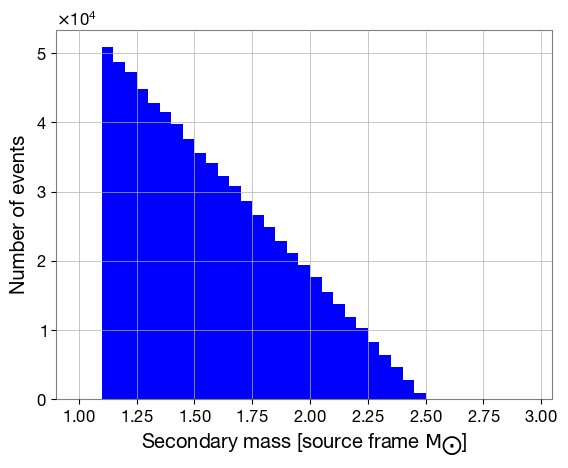

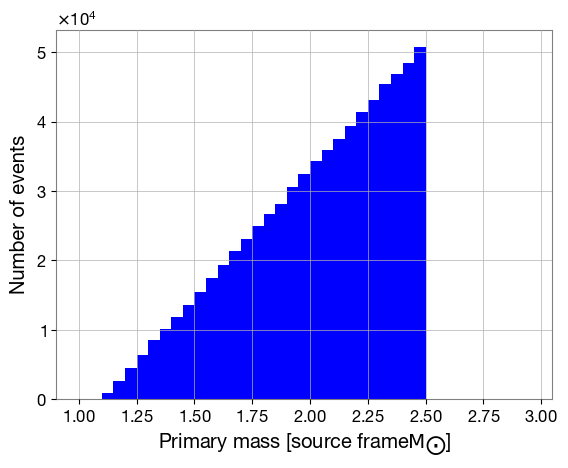

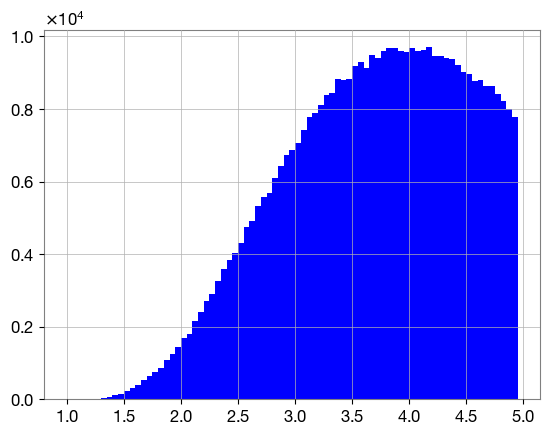

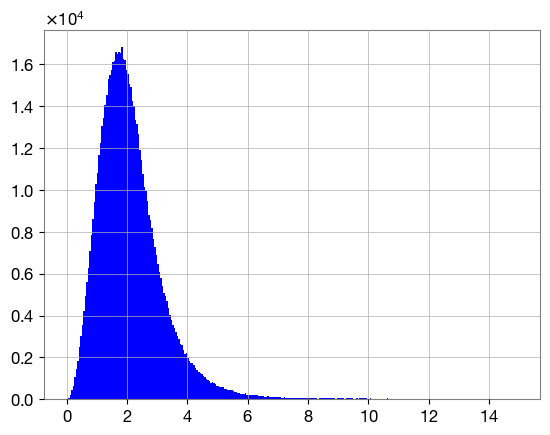

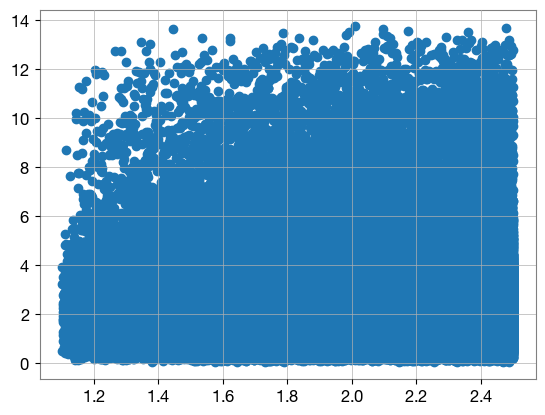

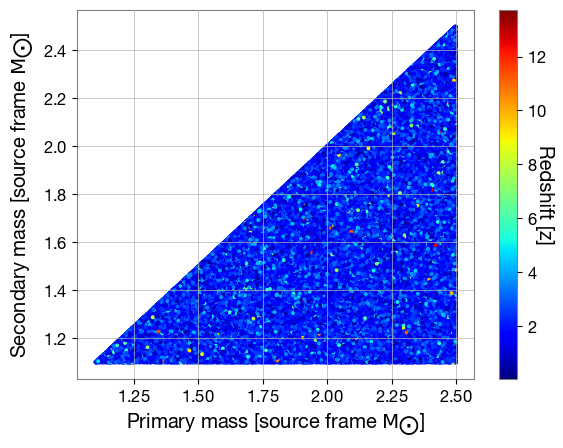

In [4]:
plt.hist(events['m2_source'], bins = np.arange(1,3,0.05), color = 'blue')
#plt.yscale('log')
plt.xlabel(r'Secondary mass [source frame $\rm M_{\bigodot}$]')
plt.ylabel('Number of events')
plt.show()

plt.hist(events['m1_source'], bins = np.arange(1,3,0.05), color = 'blue')
#plt.yscale('log')
plt.xlabel(r'Primary mass [source frame$\rm M_{\bigodot}$]')
plt.ylabel('Number of events')
plt.show()

plt.hist(events['Mc'], bins = np.arange(1,5,0.05), color = 'blue')
#plt.yscale('log')
plt.show()

plt.hist(events['z'], bins = np.arange(0,15,0.05), color = 'blue')
#plt.yscale('log')
plt.show()

plt.plot(events['m1_source'], events['z'], linestyle = '', marker = 'o')
plt.show()

plt.scatter(events['m1_source'], events['m2_source'], s=3, c=events['z'], linestyle = '', marker = 'o', cmap='jet')
plt.xlabel(r'Primary mass [source frame $\rm M_{\bigodot}$]')
plt.ylabel(r'Secondary mass [source frame $\rm M_{\bigodot}$]')
cbar = plt.colorbar()
cbar.set_label('Redshift [z]', rotation=270)
plt.show()

In [ ]:
# Generate a .csv file with the data

with open("BNS_gaussian.csv", "w", newline="") as csv_file:      # <----- create .csv file with the sources
    writer = csv.DictWriter(csv_file, fieldnames=events.keys())
    writer.writeheader()
    for i in range(len(events['m1_source'])):
        writer.writerow({key: events[key][i] for key in events.keys()})

'''# recall the data from the .csv file to a dictionary
data = {}
with open("BBH.csv", "r") as csv_file:
    reader = csv.DictReader(csv_file)
    for row in reader:
        for key, value in row.items():
            if key not in data:
                data[key] = []
            data[key].append(value)
data.keys()'''
